In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs

In [18]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [19]:
X

array([[-2.36380986, -6.8352276 ],
       [ 4.77802718, -3.92042723],
       [ 6.46984518, -4.3259318 ],
       ...,
       [ 3.26381566,  9.29900482],
       [ 3.02995079,  9.03980245],
       [ 2.51431202,  8.15843856]], shape=(1000, 2))

In [20]:
y

array([2, 0, 0, 0, 0, 2, 2, 2, 2, 1, 1, 2, 1, 2, 0, 2, 2, 0, 2, 2, 2, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1,
       1, 2, 1, 1, 0, 1, 1, 0, 1, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2, 0, 0, 2,
       2, 2, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 2, 2, 1, 1, 1, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 0, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2, 0, 2, 2,
       0, 0, 2, 0, 1, 2, 0, 1, 2, 0, 2, 1, 2, 0, 0, 0, 2, 0, 2, 2, 1, 0,
       0, 0, 2, 0, 2, 0, 2, 2, 1, 2, 0, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 2,
       1, 0, 0, 0, 1, 0, 2, 0, 2, 1, 2, 1, 2, 0, 1, 1, 1, 0, 1, 1, 2, 0,
       0, 2, 1, 0, 0, 2, 1, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2, 2,
       0, 0, 1, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 0, 2, 2, 0, 2, 1,
       2, 2, 0, 0, 0, 2, 2, 1, 1, 1, 1, 0, 1, 2, 0, 0, 0, 2, 2, 0, 1, 2,
       0, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 2, 1, 0, 0, 2, 0, 1, 1, 2, 1, 0,
       2, 1, 2, 0, 1, 1, 0, 1, 2, 1, 2, 2, 2, 2, 0, 2, 0, 0, 0, 2, 2, 0,
       1, 0, 0, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2, 1, 1,

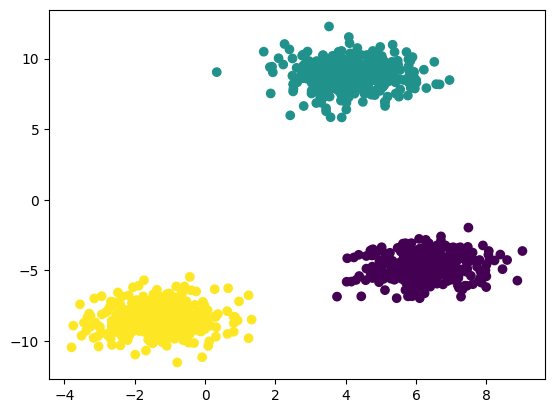

In [21]:
plt.scatter(X[:,0],X[:,1],c=y)

In [22]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [24]:
x_train_scaled=scalar.fit_transform(X_train)
x_test_scaled=scalar.transform(X_test)

In [25]:
from sklearn.cluster import KMeans

In [26]:
## use elbow method to find k 
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [27]:
wcss

[1499.9999999999995,
 548.1752379948059,
 75.14582321580835,
 62.858594688500276,
 49.871224714423484,
 46.27020602640179,
 33.177128745756846,
 31.382196410257247,
 27.863544113083798,
 24.869315641858265]

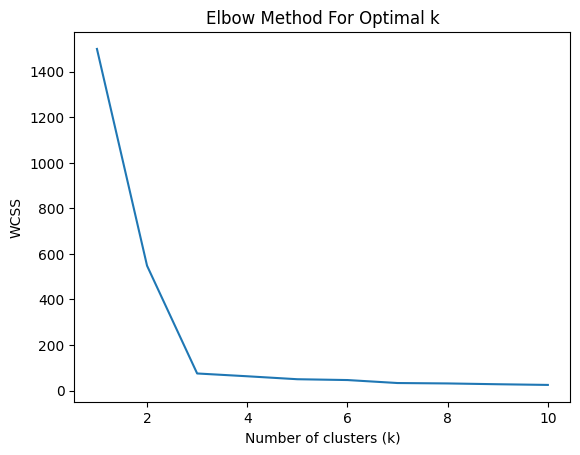

In [28]:
##plot elbow curve

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.show()

In [29]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [30]:
kmeans.fit_predict(x_train_scaled)

array([1, 0, 1, 2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 1, 1, 1, 0, 1, 0, 2, 0, 1,
       1, 1, 0, 2, 1, 0, 1, 2, 0, 1, 0, 0, 2, 0, 1, 0, 2, 0, 0, 2, 2, 2,
       1, 2, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 2, 0, 0, 1, 2, 2, 0, 2, 0, 2,
       2, 1, 0, 2, 0, 0, 2, 2, 0, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0, 1, 1,
       1, 1, 1, 0, 2, 0, 2, 1, 0, 1, 1, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2, 1,
       0, 2, 0, 1, 1, 0, 0, 0, 1, 2, 2, 2, 2, 2, 1, 1, 0, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 0, 0, 2, 2, 0, 2, 1, 1, 1, 2, 1, 0, 2, 2, 0, 0, 0, 0,
       2, 1, 1, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2, 0, 0, 0, 1, 1, 2, 0, 1, 0,
       1, 2, 1, 0, 2, 2, 2, 2, 0, 0, 2, 2, 1, 0, 2, 2, 0, 0, 2, 1, 2, 2,
       0, 0, 1, 1, 2, 0, 0, 2, 2, 0, 1, 1, 1, 0, 0, 2, 1, 0, 0, 2, 0, 1,
       0, 0, 2, 2, 2, 1, 2, 0, 1, 1, 2, 1, 1, 1, 2, 0, 2, 2, 1, 0, 2, 1,
       0, 0, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 1, 0, 2, 1, 0, 1, 1, 1, 2, 2,
       1, 1, 1, 2, 0, 2, 0, 1, 2, 1, 0, 2, 0, 1, 0,

In [32]:
y_pred=kmeans.predict(x_test_scaled)

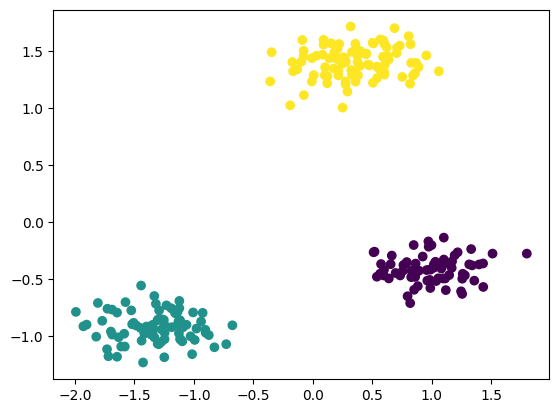

In [33]:
plt.scatter(x_test_scaled[:,0],x_test_scaled[:,1],c=y_pred)

In [ ]:
## validating k values

## 1->kneelocator
## 2->sillhoute scoring 



In [34]:
!pip install kneed 


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from kneed import KneeLocator

In [36]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [37]:
kl.elbow

np.int64(3)

In [38]:
## using silhhoute scoring 
from sklearn.metrics import silhouette_score


In [40]:
silhoutee_coefficients=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhoutee_coefficients.append(score)


In [41]:
silhoutee_coefficients

[np.float64(0.6383502439280496),
 np.float64(0.8130886154623093),
 np.float64(0.6727861762856712),
 np.float64(0.5465629975693566),
 np.float64(0.5278810339361063),
 np.float64(0.4013333720271873),
 np.float64(0.38043193542978104),
 np.float64(0.35994593708160755),
 np.float64(0.3545936235833254)]

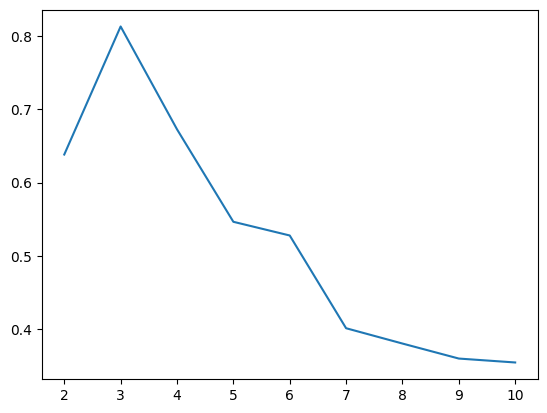

In [42]:
plt.plot(range(2,11),silhoutee_coefficients)

In [ ]:
## since silhoutee_coefficients is max for k=3
# therefor our final k is 3